# Synthetic Complete Experiment

Compact 20-seed synthetic workflow for CMDL, plain LSTM, and AC-GATE ablations. The structure matches the economics and energy notebooks: configure, optionally run, consolidate, audit, and visualize.

Run switches are off by default because the full 20-seed suite is intentionally expensive. Flip them to regenerate artifacts; otherwise the notebook reads existing outputs from `OUTPUT_ROOT`.


In [3]:
from argparse import Namespace
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

current = Path.cwd().resolve()
repo_root = next((path for path in [current, *current.parents] if (path / "config").exists() and (path / "data").exists() and (path / "experiments").exists()), None)
if repo_root is None:
    raise RuntimeError(f"Could not find repo root from {current}")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from evaluation import synthetic_comparison as comparison_module
from experiments import run_ablation as ablation_module
from experiments import run_lstm_baseline as baseline_module
from experiments import run_synthetic as cmdl_module

comparison_module = importlib.reload(comparison_module)
ablation_module = importlib.reload(ablation_module)
baseline_module = importlib.reload(baseline_module)
cmdl_module = importlib.reload(cmdl_module)

build_synthetic_comparison = comparison_module.build_synthetic_comparison
build_recovery_table = comparison_module.build_recovery_table
build_identification_table = comparison_module.build_identification_table
run_cmdl_experiment = cmdl_module.run_experiment
run_lstm_experiment = baseline_module.run_experiment
run_ablation_variant = ablation_module.run_variant
selected_variants = ablation_module.selected_variants
selected_scenarios = ablation_module.selected_scenarios
aggregate_ablation_results = ablation_module.aggregate_results
save_json = cmdl_module.save_json

SEEDS = list(range(20))
SCENARIOS = ["linear", "nonlinear"]
RUN_CMDL = True
RUN_BASELINE = True
RUN_ABLATIONS = True
ACTIVE_PLAN = "complete_20seed_20260426"
FALLBACK_PLAN = "notebook_step4_step45_formal_target"

REQUESTED_OUTPUT_ROOT = repo_root / "outputs" / "notebook_synthetic" / ACTIVE_PLAN
REQUESTED_CMDL_DIR = REQUESTED_OUTPUT_ROOT / "cmdl"
REQUESTED_BASELINE_DIR = REQUESTED_OUTPUT_ROOT / "plain_lstm"
REQUESTED_ABLATION_DIR = REQUESTED_OUTPUT_ROOT / "ablation"
FALLBACK_CMDL_DIR = repo_root / "outputs" / "notebook_step4" / "formal_target"
FALLBACK_BASELINE_DIR = repo_root / "outputs" / "notebook_step45" / "formal_target" / "baseline"
FALLBACK_ABLATION_DIR = repo_root / "outputs" / "notebook_step45" / "formal_target" / "ablation"
COMPARISON_DIR = REQUESTED_OUTPUT_ROOT / "comparison"
PLOTS_DIR = REQUESTED_OUTPUT_ROOT / "comparison_plots"

PRESET = {"epochs": 200, "patience": 20, "log_every": 10}
COMMON_ARGS = {
    "scenario": "all",
    "lr": 1e-3,
    "lambda_r": 0.1,
    "temperature": 1.0,
    "omega_transform": "softmax",
    "lambda_omega_entropy": 0.0,
    "omega_entropy_min": None,
    "omega_entropy_max": None,
    "lambda_z_anchor": 0.0,
    "z_anchor_target_sign": 1.0,
    "lag_bias_strength": 1.0,
    "grad_clip": 1.0,
    "val_fraction": 0.2,
    "device": "auto",
    "disable_mlflow": True,
}

def has_summary_artifacts(path: Path) -> bool:
    return path.exists() and any(path.glob("*/summary.json"))

RUN_ANY = RUN_CMDL or RUN_BASELINE or RUN_ABLATIONS
REQUESTED_HAS_RESULTS = any(has_summary_artifacts(path) for path in [REQUESTED_CMDL_DIR, REQUESTED_BASELINE_DIR, REQUESTED_ABLATION_DIR])
FALLBACK_HAS_RESULTS = any(has_summary_artifacts(path) for path in [FALLBACK_CMDL_DIR, FALLBACK_BASELINE_DIR, FALLBACK_ABLATION_DIR])
USE_FALLBACK_ARTIFACTS = (not RUN_ANY) and (not REQUESTED_HAS_RESULTS) and FALLBACK_HAS_RESULTS

CMDL_DIR = FALLBACK_CMDL_DIR if USE_FALLBACK_ARTIFACTS else REQUESTED_CMDL_DIR
BASELINE_DIR = FALLBACK_BASELINE_DIR if USE_FALLBACK_ARTIFACTS else REQUESTED_BASELINE_DIR
ABLATION_DIR = FALLBACK_ABLATION_DIR if USE_FALLBACK_ARTIFACTS else REQUESTED_ABLATION_DIR
ARTIFACT_SOURCE = FALLBACK_PLAN if USE_FALLBACK_ARTIFACTS else ACTIVE_PLAN
OUTPUT_ROOT = REQUESTED_OUTPUT_ROOT

for path in [REQUESTED_OUTPUT_ROOT, REQUESTED_CMDL_DIR, REQUESTED_BASELINE_DIR, REQUESTED_ABLATION_DIR, COMPARISON_DIR, PLOTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

settings = pd.Series(
    {
        "active_plan": ACTIVE_PLAN,
        "artifact_source": ARTIFACT_SOURCE,
        "seed_count_planned": len(SEEDS),
        "seeds_planned": SEEDS,
        "scenarios": SCENARIOS,
        "requested_output_root": REQUESTED_OUTPUT_ROOT,
        "cmdl_dir_resolved": CMDL_DIR,
        "baseline_dir_resolved": BASELINE_DIR,
        "ablation_dir_resolved": ABLATION_DIR,
        **PRESET,
        **COMMON_ARGS,
    },
    name="value",
).to_frame()
display(settings)

,value
active_plan,complete_20seed_20260426
artifact_source,complete_20seed_20260426
seed_count_planned,20
seeds_planned,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
scenarios,"[linear, nonlinear]"
requested_output_root,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_s...
cmdl_dir_resolved,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_s...
baseline_dir_resolved,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_s...
ablation_dir_resolved,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_s...
epochs,200


In [4]:
cmdl_rows = []
baseline_rows = []
ablation_summary_frame = pd.DataFrame()
ablation_aggregated_frame = pd.DataFrame()


def summary_exists(root: Path, experiment_name: str) -> bool:
    return (root / experiment_name / "summary.json").exists()


if RUN_CMDL:
    for seed in SEEDS:
        run_args = Namespace(**COMMON_ARGS, **PRESET, seed=seed, output_dir=str(CMDL_DIR))
        for scenario in SCENARIOS:
            experiment_name = f"cmdl_{scenario}_seed{seed}"
            if summary_exists(CMDL_DIR, experiment_name):
                print(f"Skipping existing CMDL artifact: {experiment_name}")
                continue
            result = run_cmdl_experiment(run_args, experiment_name=experiment_name, scenario=scenario)
            cmdl_rows.append({"seed": seed, "scenario": scenario, **result.metrics})
else:
    print("RUN_CMDL = False; using existing CMDL artifacts if present.")

if RUN_BASELINE:
    for seed in SEEDS:
        run_args = Namespace(**COMMON_ARGS, **PRESET, seed=seed, output_dir=str(BASELINE_DIR))
        for scenario in SCENARIOS:
            experiment_name = f"plain_lstm_{scenario}_seed{seed}"
            if summary_exists(BASELINE_DIR, experiment_name):
                print(f"Skipping existing plain-LSTM artifact: {experiment_name}")
                continue
            result = run_lstm_experiment(run_args, experiment_name=experiment_name, scenario=scenario)
            baseline_rows.append({"seed": seed, "scenario": scenario, **result.metrics})
else:
    print("RUN_BASELINE = False; using existing plain-LSTM artifacts if present.")

if RUN_ABLATIONS:
    ablation_args = Namespace(**COMMON_ARGS, **PRESET, variant="all", seeds=SEEDS, output_dir=str(ABLATION_DIR))
    summary_rows = []
    for variant in selected_variants(ablation_args.variant):
        for scenario in selected_scenarios(ablation_args.scenario):
            for seed in ablation_args.seeds:
                experiment_name = f"{variant}_{scenario}_seed{seed}"
                if summary_exists(ABLATION_DIR, experiment_name):
                    print(f"Skipping existing ablation artifact: {experiment_name}")
                    continue
                result = run_ablation_variant(args=ablation_args, variant=variant, scenario=scenario, seed=seed)
                summary_rows.append({"experiment": result.experiment_name, "variant": variant, "scenario": scenario, "seed": seed, "best_epoch": result.best_epoch, "best_val_task_loss": result.best_val_task_loss, **result.metrics})
    if summary_rows:
        ablation_summary_frame = pd.DataFrame(summary_rows)
        ablation_summary_frame.to_csv(ABLATION_DIR / "ablation_results.csv", index=False)
        save_json(ABLATION_DIR / "ablation_results.json", summary_rows)
        ablation_aggregated_frame = aggregate_ablation_results(summary_rows)
        if not ablation_aggregated_frame.empty:
            ablation_aggregated_frame.to_csv(ABLATION_DIR / "ablation_results_aggregated.csv", index=False)
    else:
        print("All requested ablation artifacts already exist.")
else:
    print("RUN_ABLATIONS = False; using existing ablation artifacts if present.")


Skipping existing CMDL artifact: cmdl_linear_seed0
Skipping existing CMDL artifact: cmdl_nonlinear_seed0
Skipping existing CMDL artifact: cmdl_linear_seed1
Skipping existing CMDL artifact: cmdl_nonlinear_seed1
Skipping existing CMDL artifact: cmdl_linear_seed2
Skipping existing CMDL artifact: cmdl_nonlinear_seed2
Skipping existing CMDL artifact: cmdl_linear_seed3
Skipping existing CMDL artifact: cmdl_nonlinear_seed3
Skipping existing CMDL artifact: cmdl_linear_seed4
Skipping existing CMDL artifact: cmdl_nonlinear_seed4
Skipping existing CMDL artifact: cmdl_linear_seed5
Skipping existing CMDL artifact: cmdl_nonlinear_seed5
Skipping existing CMDL artifact: cmdl_linear_seed6
Skipping existing CMDL artifact: cmdl_nonlinear_seed6
Skipping existing CMDL artifact: cmdl_linear_seed7
Skipping existing CMDL artifact: cmdl_nonlinear_seed7
Skipping existing CMDL artifact: cmdl_linear_seed8
Skipping existing CMDL artifact: cmdl_nonlinear_seed8
Skipping existing CMDL artifact: cmdl_linear_seed9
Skip

C:\DevSpace\PyDevspace\CMDL\visualization\omega_heatmap.py:58: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(figure_width, figure_height))


[no_ac_encoder_linear_seed11] epoch=001 train_total=0.6996 val_task=0.3823 val_kstar_mae=1.8730 val_proxy_r2=-5.2443
[no_ac_encoder_linear_seed11] epoch=010 train_total=0.1061 val_task=0.1516 val_kstar_mae=1.8493 val_proxy_r2=-5.2387
[no_ac_encoder_linear_seed11] epoch=020 train_total=0.0837 val_task=0.1043 val_kstar_mae=1.7644 val_proxy_r2=-5.2103
[no_ac_encoder_linear_seed11] epoch=030 train_total=0.0741 val_task=0.0879 val_kstar_mae=1.6844 val_proxy_r2=-5.1812
[no_ac_encoder_linear_seed11] epoch=040 train_total=0.0682 val_task=0.0842 val_kstar_mae=1.6322 val_proxy_r2=-5.1560
[no_ac_encoder_linear_seed11] epoch=050 train_total=0.0629 val_task=0.0829 val_kstar_mae=1.6250 val_proxy_r2=-5.1370
[no_ac_encoder_linear_seed11] epoch=060 train_total=0.0575 val_task=0.0840 val_kstar_mae=1.6250 val_proxy_r2=-5.1247
[no_ac_encoder_linear_seed11] epoch=070 train_total=0.0505 val_task=0.0890 val_kstar_mae=1.6250 val_proxy_r2=-5.1172
[no_ac_encoder_linear_seed11] early stopping at epoch 75
[no_ac_

<Figure size 900x1050 with 0 Axes>

<Figure size 700x600 with 0 Axes>

...

<Figure size 700x600 with 0 Axes>

<Figure size 900x1050 with 0 Axes>

<Figure size 700x600 with 0 Axes>

<Figure size 900x1050 with 0 Axes>

<Figure size 700x600 with 0 Axes>

In [5]:
def attach_seed(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return frame
    result = frame.copy()
    seed_from_experiment = result["experiment"].astype(str).str.extract(r"seed(\d+)")[0]
    seed_from_run_dir = result["run_dir"].astype(str).str.extract(r"seed(\d+)")[0]
    result["seed"] = pd.to_numeric(seed_from_experiment.fillna(seed_from_run_dir), errors="coerce").astype("Int64")
    return result

SUMMARY_METRICS = ["task_loss", "effective_kstar_mae", "effective_kstar_spearman_rho", "effective_lag_entropy_mean", "effective_lag_peak_accuracy", "proxy_signal_r2", "z_signal_spearman_rho"]

def aggregate_multiseed(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return pd.DataFrame(columns=["display_name", "family", "variant", "scenario", "n_seeds"])
    available = [column for column in SUMMARY_METRICS if column in frame.columns]
    group_columns = ["display_name", "family", "variant", "scenario"]
    working = frame.copy()
    for column in available:
        working[column] = pd.to_numeric(working[column], errors="coerce")
    grouped = working.groupby(group_columns, dropna=False)
    summary = grouped[available].agg(["mean", "std"]).reset_index()
    summary.columns = [column if isinstance(column, str) else "_".join(part for part in column if part) for column in summary.columns.to_flat_index()]
    summary = summary.merge(grouped["seed"].nunique(dropna=True).reset_index(name="n_seeds"), on=group_columns, how="left")
    if "effective_kstar_spearman_rho" in available:
        shares = grouped["effective_kstar_spearman_rho"].apply(lambda values: float((pd.to_numeric(values, errors="coerce").dropna() > 0).mean()) if not pd.to_numeric(values, errors="coerce").dropna().empty else np.nan).reset_index(name="kstar_positive_seed_share")
        summary = summary.merge(shares, on=group_columns, how="left")
    return summary.sort_values(["scenario", "family", "display_name"], na_position="last").reset_index(drop=True)

comparison = attach_seed(build_synthetic_comparison(cmdl_root=CMDL_DIR, baseline_root=BASELINE_DIR, ablation_root=ABLATION_DIR))
recovery_table = build_recovery_table(comparison)
identification_table = build_identification_table(comparison)
compact_summary = aggregate_multiseed(comparison)
significance_tables = comparison_module.build_significance_tables(comparison)

result_rows = []
for scenario in SCENARIOS:
    scenario_summary = compact_summary.loc[compact_summary["scenario"] == scenario]
    cmdl = scenario_summary.loc[scenario_summary["display_name"] == "CMDL"]
    lstm = scenario_summary.loc[scenario_summary["display_name"] == "Plain LSTM"]
    if not cmdl.empty and not lstm.empty:
        c = cmdl.iloc[0]
        b = lstm.iloc[0]
        result_rows.append({"scenario": scenario, "layer": "lag_recovery", "answer": "yes" if c.get("effective_kstar_mae_mean", np.inf) < b.get("effective_kstar_mae_mean", -np.inf) else "no", "evidence": f"CMDL kstar_mae={c.get('effective_kstar_mae_mean')}, Plain LSTM kstar_mae={b.get('effective_kstar_mae_mean')}"})
    if not scenario_summary.loc[scenario_summary["family"] == "ablation"].empty:
        result_rows.append({"scenario": scenario, "layer": "ablation_guard", "answer": "yes", "evidence": "Ablation rows are present; compare kstar MAE/rho against CMDL."})
result_log = pd.DataFrame(result_rows, columns=["scenario", "layer", "answer", "evidence"])

comparison.to_csv(COMPARISON_DIR / "synthetic_comparison.csv", index=False)
recovery_table.to_csv(COMPARISON_DIR / "synthetic_recovery_table.csv", index=False)
identification_table.to_csv(COMPARISON_DIR / "synthetic_identification_table.csv", index=False)
compact_summary.to_csv(COMPARISON_DIR / "synthetic_multiseed_summary.csv", index=False)
result_log.to_csv(COMPARISON_DIR / "synthetic_result_log.csv", index=False)
for name, frame in significance_tables.items():
    frame.to_csv(COMPARISON_DIR / name, index=False)

print(f"comparison rows = {len(comparison)}")
display(compact_summary)
display(result_log)

comparison rows = 200


,display_name,family,variant,scenario,task_loss_mean,task_loss_std,effective_kstar_mae_mean,effective_kstar_mae_std,effective_kstar_spearman_rho_mean,effective_kstar_spearman_rho_std,effective_lag_entropy_mean_mean,effective_lag_entropy_mean_std,effective_lag_peak_accuracy_mean,effective_lag_peak_accuracy_std,proxy_signal_r2_mean,proxy_signal_r2_std,z_signal_spearman_rho_mean,z_signal_spearman_rho_std,n_seeds,kstar_positive_seed_share
0,No AC Encoder,ablation,no_ac_encoder,linear,0.062946,0.005430,1.931170,0.162463,0.000000,0.000000,2.001045,0.071390,0.13900,0.030245,-1.476138e+16,4.750151e+16,0.000000,0.000000,20,0.0
1,No Recon Regularization,ablation,no_recon_regularization,linear,0.036329,0.004310,1.159246,0.226639,0.944675,0.078489,1.904514,0.085108,0.34700,0.072555,8.993343e-01,9.071034e-02,0.954408,0.081383,20,1.0
2,Uniform Lag,ablation,uniform_lag,linear,0.069512,0.002694,1.912750,0.087577,0.000000,0.000000,2.302585,0.000000,0.00000,0.000000,8.483472e-01,1.571878e-01,0.945730,0.091668,20,0.0
3,CMDL,cmdl,NaN,linear,0.036238,0.004377,1.159093,0.226536,0.944896,0.078103,1.905189,0.085072,0.34675,0.072171,8.995846e-01,9.044959e-02,0.954648,0.080977,20,1.0
4,Plain LSTM,plain_lstm,NaN,linear,0.069503,0.002897,1.706720,0.090700,0.356054,0.065714,2.148185,0.019232,0.12875,0.018699,NaN,NaN,NaN,NaN,20,1.0
5,No AC Encoder,ablation,no_ac_encoder,nonlinear,0.066058,0.018424,2.435219,0.260711,0.000000,0.000000,1.820658,0.113915,0.27675,0.150493,-2.850363e+16,5.384774e+16,0.000000,0.000000,20,0.0
6,No Recon Regularization,ablation,no_recon_regularization,nonlinear,0.037843,0.006660,1.466841,0.248370,0.908675,0.204805,1.833409,0.082700,0.48850,0.041330,8.898297e-01,1.934375e-01,0.943500,0.212479,20,1.0
7,Uniform Lag,ablation,uniform_lag,nonlinear,0.093817,0.008114,3.101750,0.097809,0.000000,0.000000,2.302585,0.000000,0.39300,0.027549,8.270833e-01,2.264659e-01,0.911128,0.180868,20,0.0
8,CMDL,cmdl,NaN,nonlinear,0.037825,0.006533,1.466921,0.248345,0.906988,0.212393,1.833295,0.082756,0.48800,0.041403,8.886551e-01,1.987195e-01,0.945222,0.204769,20,1.0
9,Plain LSTM,plain_lstm,NaN,nonlinear,0.092684,0.006085,2.610799,0.137687,0.343930,0.092467,2.089441,0.028125,0.22725,0.023923,NaN,NaN,NaN,NaN,20,1.0


,scenario,layer,answer,evidence
0,linear,lag_recovery,yes,"CMDL kstar_mae=1.159093333899975, Plain LSTM k..."
1,linear,ablation_guard,yes,Ablation rows are present; compare kstar MAE/r...
2,nonlinear,lag_recovery,yes,"CMDL kstar_mae=1.466921085000038, Plain LSTM k..."
3,nonlinear,ablation_guard,yes,Ablation rows are present; compare kstar MAE/r...


,display_name,family,scenario,experiment,task_loss,effective_kstar_mae,effective_kstar_spearman_rho,effective_lag_entropy_mean,effective_lag_peak_accuracy,best_epoch
0,CMDL,cmdl,linear,cmdl_linear_seed1,0.032573,0.784722,0.984859,1.907590,0.420,131
1,No Recon Regularization,ablation,linear,no_recon_regularization_linear_seed1,0.034293,0.787703,0.984784,1.892249,0.435,116
2,No Recon Regularization,ablation,linear,no_recon_regularization_linear_seed4,0.036919,0.877278,0.978406,1.902520,0.415,93
3,CMDL,cmdl,linear,cmdl_linear_seed4,0.036917,0.877297,0.978406,1.902519,0.415,93
4,No Recon Regularization,ablation,linear,no_recon_regularization_linear_seed3,0.035664,0.958679,0.980834,1.860184,0.370,111
...,...,...,...,...,...,...,...,...,...,...
195,No AC Encoder,ablation,nonlinear,no_ac_encoder_nonlinear_seed2,0.091261,3.187236,0.000000,2.070890,0.105,78
196,Uniform Lag,ablation,nonlinear,uniform_lag_nonlinear_seed19,0.092649,3.195000,0.000000,2.302585,0.390,34
197,Uniform Lag,ablation,nonlinear,uniform_lag_nonlinear_seed13,0.104385,3.215000,0.000000,2.302585,0.410,29
198,Uniform Lag,ablation,nonlinear,uniform_lag_nonlinear_seed4,0.078740,3.230000,0.000000,2.302585,0.450,48


,display_name,family,scenario,experiment,task_loss,proxy_signal_r2,z_signal_spearman_rho,best_epoch
0,Uniform Lag,ablation,linear,uniform_lag_linear_seed11,0.071249,9.537061e-01,0.990887,32
1,Uniform Lag,ablation,linear,uniform_lag_linear_seed12,0.064591,9.535939e-01,0.984676,50
2,CMDL,cmdl,linear,cmdl_linear_seed19,0.039335,9.522169e-01,0.991826,106
3,No Recon Regularization,ablation,linear,no_recon_regularization_linear_seed19,0.039316,9.522162e-01,0.991826,106
4,Uniform Lag,ablation,linear,uniform_lag_linear_seed18,0.070107,9.513798e-01,0.991391,39
...,...,...,...,...,...,...,...,...
155,No AC Encoder,ablation,nonlinear,no_ac_encoder_nonlinear_seed19,0.054898,-3.504692e+16,0.000000,199
156,No AC Encoder,ablation,nonlinear,no_ac_encoder_nonlinear_seed12,0.075024,-9.209752e+16,0.000000,59
157,No AC Encoder,ablation,nonlinear,no_ac_encoder_nonlinear_seed6,0.042740,-1.181520e+17,0.000000,134
158,No AC Encoder,ablation,nonlinear,no_ac_encoder_nonlinear_seed13,0.073033,-1.492615e+17,0.000000,49


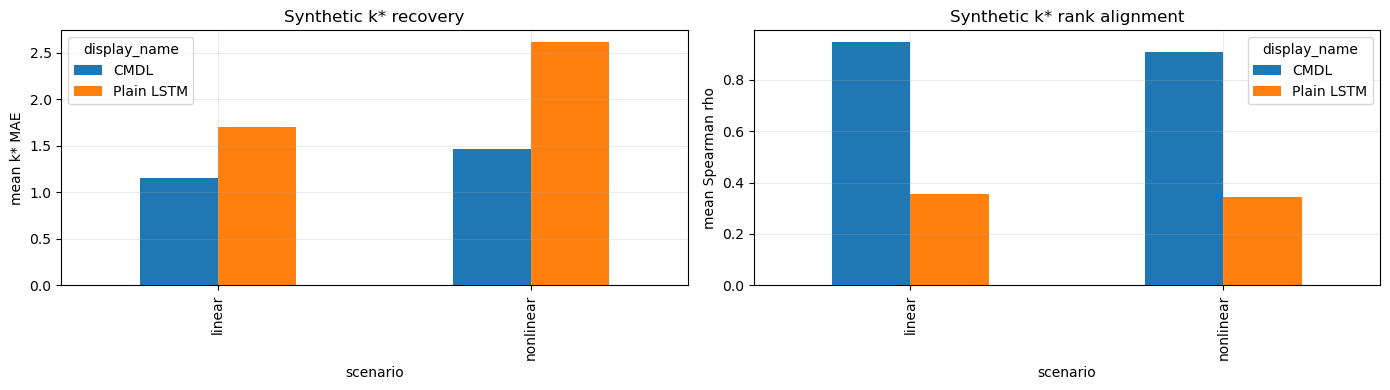

Saved plot to C:\DevSpace\PyDevspace\CMDL\outputs\notebook_synthetic\complete_20seed_20260426\comparison_plots\synthetic_multiseed_summary.png


In [6]:
if compact_summary.empty:
    print("No synthetic artifacts found yet. Enable run switches or point OUTPUT_ROOT to an existing run directory.")
else:
    display(recovery_table)
    display(identification_table)
    plot_frame = compact_summary.loc[compact_summary["display_name"].isin(["CMDL", "Plain LSTM"])].copy()
    if not plot_frame.empty:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        plot_frame.pivot(index="scenario", columns="display_name", values="effective_kstar_mae_mean").plot(kind="bar", ax=axes[0])
        axes[0].set_title("Synthetic k* recovery")
        axes[0].set_ylabel("mean k* MAE")
        axes[0].grid(alpha=0.25)
        plot_frame.pivot(index="scenario", columns="display_name", values="effective_kstar_spearman_rho_mean").plot(kind="bar", ax=axes[1])
        axes[1].set_title("Synthetic k* rank alignment")
        axes[1].set_ylabel("mean Spearman rho")
        axes[1].grid(alpha=0.25)
        fig.tight_layout()
        plot_path = PLOTS_DIR / "synthetic_multiseed_summary.png"
        fig.savefig(plot_path, dpi=160, bbox_inches="tight")
        display(fig)
        plt.close(fig)
        print(f"Saved plot to {plot_path}")
